1. เราเรียกใช้คำสั่ง head() ของ Pandas(จะโชว์แค่5แถวแรกเป็นค่าเริ่มต้น) เพื่อเช็คว่าเจอข้อมูลมั้ย

In [ ]:
import pandas as pd

df = pd.read_csv("../data/tourism59-68.csv")

df.head()

2. นับว่ามีกี่แถวในแต่ละปี

In [ ]:
df.groupby("ปี").size()

3. ดูว่ามีชื่ออุทยานซ้ำในปีเดียวกันไหม

In [ ]:
df.duplicated(subset=["ปี", "อุทยานแห่งชาติ"]).sum()

4. ตรวจว่ามีชื่ออุทยานเดียวกันซ้ำในปีเดียวกันหรือไม่
5. ตรวจว่ามีค่า Missing หรือช่องว่างในแต่ละคอลัมน์หรือไม่
    isna() = เช็กว่าช่องไหนไม่มีข้อมูล
    sum() = นับว่าหายกี่ช่องในแต่ละ column

In [ ]:
print("จำนวนข้อมูลซ้ำ:")
print(df.duplicated(subset=["ปี", "อุทยานแห่งชาติ"]).sum())

print("\nจำนวน Missing Values:")
df.isna().sum()

6. ตรวจว่าคอลัมน์จำนวนผู้เข้าชมรายเดือนถูกเก็บเป็นตัวเลขหรือไม่

In [ ]:
df.dtypes

สรุปชนิดข้อมูล

- ปี เป็นชนิด int64 ใช้เก็บค่าปีในรูปแบบตัวเลข
- อุทยานแห่งชาติ เป็นชนิด str ใช้เก็บชื่ออุทยาน
- สังกัด เป็นชนิด str ใช้เก็บชื่อหน่วยงานที่รับผิดชอบ
- คอลัมน์รายเดือนตั้งแต่ ต.ค. ถึง ก.ย. เป็นชนิด int64 ใช้เก็บจำนวนผู้เข้าชมในแต่ละเดือน
= นำข้อมูลไปคำนวณ วิเคราะห์ และสร้าง Visualization ต่อได้

7. ตรวจค่าผิดปกติว่าคอลัมน์จำนวนผู้เข้าชมรายเดือนมีค่าติดลบหรือไม่
 month_colsในไฟล์ = ' ต.ค. ' เลยนำมาลบช่องข้างหน้าและหลังออกก่อนเป็น 'ต.ค.'

In [ ]:
df.columns = df.columns.str.strip()
month_cols = ["ต.ค.", "พ.ย.", "ธ.ค.", "ม.ค.", "ก.พ.", "มี.ค.",
              "เม.ย.", "พ.ค.", "มิ.ย.", "ก.ค.", "ส.ค.", "ก.ย."]

print("จำนวนค่าติดลบ:")
print((df[month_cols] < 0).sum())

8. ตรวจจำนวนค่า 0 ในข้อมูลผู้เข้าชมรายเดือน เพื่อดูว่ามีเดือนหรืออุทยานใดที่ไม่มีผู้เข้าชมหรืออาจมีเหตุจากการปิดอุทยาน

In [ ]:
print("จำนวนค่า 0 ในแต่ละเดือน:")
print((df[month_cols] == 0).sum())

9. ตรวจค่า 0 แยกตามปี
    ในปีนั้น แต่ละเดือนมีอุทยานกี่แถวที่ค่าเป็น 0

In [ ]:
zero_by_year = (df[month_cols] == 0).groupby(df["ปี"]).sum()

zero_by_year

10. รวมจำนวนช่องที่มีผู้เข้าชมเป็น 0 ของทั้ง 12 เดือนในแต่ละปี
    axis=1 = รวมตามแนวนอนของแต่ละแถว

In [ ]:
zero_by_year["รวม"] = zero_by_year.sum(axis=1)

zero_by_year["รวม"]

ตรวจว่าค่า 0 ในปี 2563–2564 กระจุกตัวอยู่ในเดือนใด
loc = เลือกแถวตามชื่อ/index ที่ต้องการ

In [ ]:
zero_by_year.loc[[2563, 2564]]

พบจำนวนค่า 0 สูงผิดปกติในปีงบประมาณ 2563 และ 2564

โดยปี 2563 มีค่า 0 จำนวนมากในช่วงเดือนเมษายนถึงมิถุนายน โดยเฉพาะเดือนเมษายนและพฤษภาคมที่มีอุทยาน 155 แห่งมีจำนวนผู้เข้าชมเป็น 0 ซึ่งอาจเกี่ยวข้องกับการปิดอุทยานและข้อจำกัดด้านการเดินทางในช่วง COVID-19

ข้อมูลในช่วงดังกล่าวจึงควรได้รับการพิจารณาแยกจากฤดูกาลท่องเที่ยวปกติในการวิเคราะห์ภายหลัง

11. 
ตรวจว่าอุทยานแต่ละแห่งมีข้อมูลปรากฏครบทุกปีตั้งแต่ พ.ศ. 2559–2568 หรือไม่
    ["ปี"].nunique() = นับว่าแต่ละอุทยานมี ปีที่ไม่ซ้ำกันกี่ปี

In [ ]:
park_year_count = df.groupby("อุทยานแห่งชาติ")["ปี"].nunique()

park_year_count.sort_values()

12. ตรวจการกระจายของจำนวนปีต่ออุทยาน

ตรวจจำนวนอุทยานที่มีข้อมูลตั้งแต่ 1 ถึง 10 ปี เพื่อดูความต่อเนื่องของข้อมูล

In [25]:
park_year_count.value_counts().sort_index()

ปี
1      24
2      14
3       5
4       1
5       1
7       9
8      15
9       6
10    123
Name: count, dtype: int64

13. ตรวจปีแรกและปีสุดท้ายของแต่ละอุทยาน

ตรวจช่วงปีที่แต่ละอุทยานปรากฏใน Dataset เพื่อแยกว่าเป็นอุทยานที่เพิ่มเข้ามาทีหลัง หรือมีข้อมูลขาดหายระหว่างช่วงเวลา

In [ ]:
park_year_summary = df.groupby("อุทยานแห่งชาติ")["ปี"].agg(
    first_year="min",
    last_year="max",
    year_count="nunique"
)
### pd.set_option("display.max_rows", None) โชว์ทั้งหมด
park_year_summary.sort_values(["year_count", "first_year"])

14. ตรวจปีที่ขาดหายระหว่างช่วงข้อมูล

ตรวจว่าอุทยานใดมีปีขาดหายอยู่ระหว่างปีแรกและปีสุดท้ายที่ปรากฏใน Dataset

In [ ]:
missing_between = (
    df.groupby("อุทยานแห่งชาติ")["ปี"]
    .apply(
        lambda years: sorted(
            set(range(years.min(), years.max() + 1)) - set(years)
        )
    )
)

missing_between[missing_between.apply(len) > 0]

15. ตรวจความแตกต่างของชื่ออุทยาน

ตรวจกรณีที่อุทยานเดียวกันถูกบันทึกด้วยชื่อที่แตกต่างกันตามสถานะ เช่น `(เตรียมการ)` และ `(เตรียมการฯ)` ซึ่งอาจทำให้ระบบมองเป็นคนละอุทยาน

In [ ]:
df["ชื่ออุทยาน_clean"] = (
    df["อุทยานแห่งชาติ"]
    .str.replace(r"\s*\(เตรียมการฯ?\)", "", regex=True)
    .str.strip()
)

df[["อุทยานแห่งชาติ", "ชื่ออุทยาน_clean"]].drop_duplicates()

16. ตรวจจำนวนอุทยานหลังทำความสะอาดชื่อ

เปรียบเทียบจำนวนชื่ออุทยานก่อนและหลังการลบคำระบุสถานะ เช่น `(เตรียมการ)` และ `(เตรียมการฯ)`

In [ ]:
print("จำนวนชื่ออุทยานก่อน Cleaning:")
print(df["อุทยานแห่งชาติ"].nunique())

print("\nจำนวนชื่ออุทยานหลัง Cleaning:")
print(df["ชื่ออุทยาน_clean"].nunique())

แปลว่ามีชื่อประมาณ 30 รายการ ที่ต่างกันเพราะมีคำอย่าง (เตรียมการ) / (เตรียมการฯ) พ่วงอยู่ ทำให้ Pandas เคยมองเป็นคนละชื่อ

เช็กว่าหลังรวมชื่อแล้ว มีข้อมูลชนกันในปีเดียวกันไหม

In [ ]:
print("จำนวนข้อมูลซ้ำหลัง Cleaning ชื่อ:")
print(
    df.duplicated(
        subset=["ปี", "ชื่ออุทยาน_clean"]
    ).sum()
)

17. ตรวจปีที่ขาดหายหลังทำความสะอาดชื่ออุทยาน

ตรวจอีกครั้งว่าอุทยานใดมีปีขาดหายอยู่ระหว่างปีแรกและปีสุดท้าย หลังจากรวมชื่ออุทยานที่แตกต่างกันจากสถานะ (เตรียมการ)

In [ ]:
missing_between_clean = (
    df.groupby("ชื่ออุทยาน_clean")["ปี"]
    .apply(
        lambda years: sorted(
            set(range(years.min(), years.max() + 1)) - set(years)
        )
    )
)

missing_between_clean[missing_between_clean.apply(len) > 0]

18. ปรับรูปแบบชื่ออุทยานเพิ่มเติม

ปรับความแตกต่างด้านช่องว่าง เครื่องหมายขีด และอักขระที่มองไม่เห็น เพื่อให้ชื่ออุทยานมีรูปแบบสม่ำเสมอมากขึ้น

In [ ]:
df["ชื่ออุทยาน_clean2"] = (
    df["ชื่ออุทยาน_clean"]
    .str.normalize("NFC")
    .str.replace("\u200b", "", regex=False)
    .str.replace(r"\s*-\s*", "-", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("หลัง Cleaning รอบแรก:", df["ชื่ออุทยาน_clean"].nunique())
print("หลัง Cleaning รอบสอง:", df["ชื่ออุทยาน_clean2"].nunique())

19. ตรวจชื่อที่ถูกรวมหลัง Cleaning รอบสอง

ตรวจชื่ออุทยานที่ถูกมองว่าเป็นชื่อเดียวกันหลังปรับรูปแบบช่องว่างและเครื่องหมายขีด

In [ ]:
merged_names = (
    df.groupby("ชื่ออุทยาน_clean2")["ชื่ออุทยาน_clean"]
    .unique()
)

merged_names[merged_names.apply(len) > 1]

20. ตรวจปีที่ขาดหายหลัง Cleaning รอบสอง

ตรวจอีกครั้งว่าอุทยานใดมีปีขาดหายระหว่างช่วงข้อมูล หลังจากปรับรูปแบบชื่อให้สม่ำเสมอมากขึ้น

In [ ]:
missing_between_clean2 = (
    df.groupby("ชื่ออุทยาน_clean2")["ปี"]
    .apply(
        lambda years: sorted(
            set(range(years.min(), years.max() + 1)) - set(years)
        )
    )
)

missing_between_clean2[missing_between_clean2.apply(len) > 0]

21. ตรวจชื่ออุทยานที่อาจเป็นชื่อเดียวกัน

สร้างชื่อสำหรับเปรียบเทียบโดยตัดช่องว่างและเครื่องหมายขีดออก เพื่อค้นหารูปแบบชื่อที่อาจหมายถึงอุทยานเดียวกัน โดยยังไม่แก้ไขข้อมูลจริง

In [ ]:
df["ชื่ออุทยาน_key"] = (
    df["ชื่ออุทยาน_clean2"]
    .str.replace(r"[\s\-–—]", "", regex=True)
    .str.strip()
)

candidate_names = (
    df.groupby("ชื่ออุทยาน_key")["ชื่ออุทยาน_clean2"]
    .unique()
)

candidate_names[candidate_names.apply(len) > 1]

22. ตรวจช่วงปีของชื่ออุทยานที่อาจซ้ำกัน

ตรวจว่ารูปแบบชื่อ ภูจอง-นายอย และ ภูจองนายอย
ปรากฏในปีใดบ้าง ก่อนตัดสินใจรวมเป็นชื่อเดียวกัน

In [ ]:
df[
    df["ชื่ออุทยาน_clean2"].isin(["ภูจอง-นายอย", "ภูจองนายอย"])
][["ปี", "อุทยานแห่งชาติ", "ชื่ออุทยาน_clean2"]].sort_values("ปี")

23. รวมชื่ออุทยานที่ตรวจสอบแล้ว

พบว่า ภูจอง-นายอย ในปี 2559–2560 และ ภูจองนายอย ในปี 2561–2568
เป็นลำดับข้อมูลต่อเนื่องกัน จึงปรับให้ใช้ชื่อเดียวกันเพื่อให้การวิเคราะห์ข้ามปีถูกต้อง

In [ ]:
df["ชื่ออุทยาน_final"] = df["ชื่ออุทยาน_clean2"].replace({
    "ภูจอง-นายอย": "ภูจองนายอย"
})

print("จำนวนชื่อก่อนรวม:", df["ชื่ออุทยาน_clean2"].nunique())
print("จำนวนชื่อหลังรวม:", df["ชื่ออุทยาน_final"].nunique())

print("\nข้อมูลซ้ำหลังรวมชื่อ:")
print(
    df.duplicated(
        subset=["ปี", "ชื่ออุทยาน_final"]
    ).sum()
)

#ตรวจปีหายอีกที
missing_between_final = (
    df.groupby("ชื่ออุทยาน_final")["ปี"]
    .apply(
        lambda years: sorted(
            set(range(years.min(), years.max() + 1)) - set(years)
        )
    )
)

missing_between_final[missing_between_final.apply(len) > 0]

24. ตรวจชื่ออุทยานที่สะกดใกล้เคียงกัน

ตรวจสอบ น้ำตกชีโป และ น้ำตกซีโป ว่าเป็นข้อมูลต่อเนื่องกันหรือไม่
ก่อนตัดสินใจรวมชื่อในการทำความสะอาดข้อมูล
    ชื่อคล้ายกัน
    ปีต่อเนื่องกัน
    สังกัดเดียวกัน

In [ ]:
df[
    df["ชื่ออุทยาน_final"].isin(["น้ำตกชีโป", "น้ำตกซีโป"])
][
    ["ปี", "อุทยานแห่งชาติ", "ชื่ออุทยาน_final", "สังกัด"]
].sort_values("ปี")

25. ปรับชื่ออุทยานน้ำตกซีโป

พบว่าข้อมูลมีการใช้ชื่อ น้ำตกชีโป และ น้ำตกซีโป สลับกันในแต่ละปี
โดยทั้งสองชื่ออยู่ภายใต้สังกัดเดียวกัน และข้อมูลจากกรมอุทยานแห่งชาติใช้ชื่อ
อุทยานแห่งชาติน้ำตกซีโป จึงปรับให้ใช้ชื่อ 'น้ำตกซีโป' เป็นชื่อมาตรฐาน
สำหรับการวิเคราะห์

In [53]:
df["ชื่ออุทยาน_final"] = df["ชื่ออุทยาน_final"].replace({
    "น้ำตกชีโป": "น้ำตกซีโป"
})

print("จำนวนชื่ออุทยานหลังรวม:")
print(df["ชื่ออุทยาน_final"].nunique())

print("\nจำนวนข้อมูลซ้ำ:")
print(
    df.duplicated(
        subset=["ปี", "ชื่ออุทยาน_final"]
    ).sum()
)

#ตรวจปีหายอีกที
missing_between_final = (
    df.groupby("ชื่ออุทยาน_final")["ปี"]
    .apply(
        lambda years: sorted(
            set(range(years.min(), years.max() + 1)) - set(years)
        )
    )
)

remaining_missing = missing_between_final[
    missing_between_final.apply(len) > 0
]

remaining_missing



จำนวนชื่ออุทยานหลังรวม:
165

จำนวนข้อมูลซ้ำ:
0


ชื่ออุทยาน_final
ดอยสอยมาลัย              [2562]
ต้นสักใหญ่               [2560]
ถ้ำหลวง-ขุนน้ำนางนอน     [2562]
ผาแดง                    [2560]
ภูผายา                   [2561]
ภูผาเทิบ                 [2560]
ภูสวนทราย                [2560]
ภูหินจอมธาตุ-ภูพระบาท    [2562]
แก่งเจ็ดแคว              [2561]
แควน้อย                  [2562]
แม่ยวมฝั่งซ้าย           [2561]
แม่สะเรียง               [2562]
ไม้กลายเป็นหิน           [2561]
Name: ปี, dtype: object

26. ตรวจรายละเอียดอุทยานที่มีปีขาด

ตรวจปีที่มีข้อมูล ชื่อเดิม และสังกัดของอุทยานที่ยังพบปีขาด
เพื่อหาสาเหตุก่อนตัดสินใจแก้ไขข้อมูล

In [ ]:
parks_with_missing = remaining_missing.index

missing_detail = (
    df[df["ชื่ออุทยาน_final"].isin(parks_with_missing)]
    .groupby("ชื่ออุทยาน_final")
    .agg(
        ปีที่มีข้อมูล=("ปี", lambda x: sorted(x.unique())),
        ชื่อเดิม=("อุทยานแห่งชาติ", lambda x: list(x.unique())),
        สังกัด=("สังกัด", lambda x: list(x.unique()))
    )
)

missing_detail

In [ ]:
missing_summary = remaining_missing.reset_index()

missing_summary.columns = ["อุทยาน", "ปีที่ขาด"]

missing_summary

27. ตรวจความครบถ้วนของข้อมูลปี 2568

ตรวจว่าปีงบประมาณ 2568 มีข้อมูลผู้เข้าชมครบทั้ง 12 เดือน
ก่อนนำไปเปรียบเทียบกับปีอื่น

In [ ]:
df_2568 = df[df["ปี"] == 2568]

print("จำนวนอุทยานในปี 2568:")
print(len(df_2568))

print("\nจำนวนข้อมูลในแต่ละเดือน:")
print(df_2568[month_cols].notna().sum())

print("\nยอดผู้เข้าชมรวมในแต่ละเดือน:")
print(df_2568[month_cols].sum())

In [57]:
#เปลี่ยนข้อมูลเป็น long format

tourism_long = df.melt(
    id_vars=["ปี", "ชื่ออุทยาน_final", "สังกัด"],
    value_vars=month_cols,
    var_name="เดือน",
    value_name="จำนวนนักท่องเที่ยว"
)

tourism_long.head(10)

,ปี,ชื่ออุทยาน_final,สังกัด,เดือน,จำนวนนักท่องเที่ยว
0,2559,เขาใหญ่,สำนักบริหารพื้นที่อนุรักษ์ที่ 1,ต.ค.,130757
1,2559,ทับลาน,สำนักบริหารพื้นที่อนุรักษ์ที่ 1,ต.ค.,1866
2,2559,ปางสีดา,สำนักบริหารพื้นที่อนุรักษ์ที่ 1,ต.ค.,21160
3,2559,ตาพระยา,สำนักบริหารพื้นที่อนุรักษ์ที่ 1,ต.ค.,15
4,2559,น้ำตกสามหลั่น,สำนักบริหารพื้นที่อนุรักษ์ที่ 1 สาขาสระบุรี,ต.ค.,6727
5,2559,น้ำตกเจ็ดสาวน้อย,สำนักบริหารพื้นที่อนุรักษ์ที่ 1 สาขาสระบุรี,ต.ค.,46898
6,2559,น้ำตกพลิ้ว,สำนักบริหารพื้นที่อนุรักษ์ที่ 2,ต.ค.,45546
7,2559,เขาชะเมา-เขาวง,สำนักบริหารพื้นที่อนุรักษ์ที่ 2,ต.ค.,22600
8,2559,เขาคิชฌกูฎ,สำนักบริหารพื้นที่อนุรักษ์ที่ 2,ต.ค.,13499
9,2559,เขาแหลมหญ้า-หมู่เกาะเสม็ด,สำนักบริหารพื้นที่อนุรักษ์ที่ 2,ต.ค.,22596


28. ตรวจขนาดข้อมูลหลังแปลงเป็น Long Format

ตรวจจำนวนแถวและคอลัมน์หลังจากแปลงข้อมูลจาก Wide Format เป็น Long Format

In [58]:
tourism_long.shape

(18516, 5)

29. แปลงปีงบประมาณเป็นปีปฏิทิน

เพิ่มเลขเดือนและปีปฏิทินจริง เพื่อให้สามารถเชื่อมข้อมูลนักท่องเที่ยว
กับข้อมูลสภาพอากาศและข้อมูลรายเดือนจากแหล่งอื่นได้อย่างถูกต้อง

In [60]:
month_map = {
    "ม.ค.": 1,
    "ก.พ.": 2,
    "มี.ค.": 3,
    "เม.ย.": 4,
    "พ.ค.": 5,
    "มิ.ย.": 6,
    "ก.ค.": 7,
    "ส.ค.": 8,
    "ก.ย.": 9,
    "ต.ค.": 10,
    "พ.ย.": 11,
    "ธ.ค.": 12
}

tourism_long["เลขเดือน"] = tourism_long["เดือน"].map(month_map)

tourism_long["ปีปฏิทิน"] = (
    tourism_long["ปี"]
    - (tourism_long["เลขเดือน"] >= 10).astype(int)
)

tourism_long[
    tourism_long["ปี"] == 2568
][
    ["ปี", "เดือน", "เลขเดือน", "ปีปฏิทิน"]
].drop_duplicates()

,ปี,เดือน,เลขเดือน,ปีปฏิทิน
1387,2568,ต.ค.,10,2567
2930,2568,พ.ย.,11,2567
4473,2568,ธ.ค.,12,2567
6016,2568,ม.ค.,1,2568
7559,2568,ก.พ.,2,2568
9102,2568,มี.ค.,3,2568
10645,2568,เม.ย.,4,2568
12188,2568,พ.ค.,5,2568
13731,2568,มิ.ย.,6,2568
15274,2568,ก.ค.,7,2568


30. สร้างวันที่สำหรับการวิเคราะห์แบบ Time Series

แปลงปีปฏิทินจาก พ.ศ. เป็น ค.ศ. และสร้างวันที่ในรูปแบบมาตรฐาน
เพื่อใช้เชื่อมกับข้อมูลสภาพอากาศ ฐานข้อมูล และการวิเคราะห์ตามช่วงเวลา
ข้อมูล Weather / Database ส่วนใหญ่จะใช้ ค.ศ. เช่น 2024-10-01

In [62]:
tourism_long["ปีค.ศ."] = tourism_long["ปีปฏิทิน"] - 543

tourism_long["วันที่"] = pd.to_datetime(
    dict(
        year=tourism_long["ปีค.ศ."],
        month=tourism_long["เลขเดือน"],
        day=1
    )
)

tourism_long[
    tourism_long["ปี"] == 2568
][
    ["ปี", "เดือน", "ปีปฏิทิน", "ปีค.ศ.", "วันที่"]
].drop_duplicates()

,ปี,เดือน,ปีปฏิทิน,ปีค.ศ.,วันที่
1387,2568,ต.ค.,2567,2024,2024-10-01
2930,2568,พ.ย.,2567,2024,2024-11-01
4473,2568,ธ.ค.,2567,2024,2024-12-01
6016,2568,ม.ค.,2568,2025,2025-01-01
7559,2568,ก.พ.,2568,2025,2025-02-01
9102,2568,มี.ค.,2568,2025,2025-03-01
10645,2568,เม.ย.,2568,2025,2025-04-01
12188,2568,พ.ค.,2568,2025,2025-05-01
13731,2568,มิ.ย.,2568,2025,2025-06-01
15274,2568,ก.ค.,2568,2025,2025-07-01


31. ตรวจคุณภาพข้อมูลหลัง Transform

ตรวจ Missing Values และข้อมูลซ้ำหลังจากแปลงเป็น Long Format
และเพิ่มข้อมูลเดือน ปีปฏิทิน และวันที่แล้ว

In [ ]:
print("จำนวน Missing Values:")
print(tourism_long.isna().sum()) #Transform แล้วมีช่องไหนกลายเป็น NaN หรือไม่

print("\nจำนวนข้อมูลซ้ำ:") #เช็กว่าใน ปีเดียวกัน + อุทยานเดียวกัน + เดือนเดียวกัน มีมากกว่า 1 แถวไหม
print(
    tourism_long.duplicated(
        subset=["ปี", "ชื่ออุทยาน_final", "เดือน"]
    ).sum()
)



32. สร้าง Clean Dataset

จัดชื่อคอลัมน์ให้อยู่ในรูปแบบมาตรฐาน เรียงข้อมูลตามวันที่และอุทยาน
จากนั้นบันทึกเป็นไฟล์ใหม่สำหรับใช้ในขั้นตอน Database และ Analytics
โดยเก็บ Raw Data ต้นฉบับไว้โดยไม่แก้ไข

In [65]:
tourism_clean = tourism_long.rename(columns={
    "ปี": "fiscal_year_be",
    "ชื่ออุทยาน_final": "park_name",
    "สังกัด": "office",
    "เดือน": "month_th",
    "จำนวนนักท่องเที่ยว": "visitors",
    "เลขเดือน": "month_num",
    "ปีปฏิทิน": "calendar_year_be",
    "ปีค.ศ.": "calendar_year_ce",
    "วันที่": "date"
})

tourism_clean = (
    tourism_clean
    .sort_values(["date", "park_name"])
    .reset_index(drop=True)
)

tourism_clean.head()

,fiscal_year_be,park_name,office,month_th,visitors,month_num,calendar_year_be,calendar_year_ce,date
0,2559,กุยบุรี,สำนักบริหารพื้นที่อนุรักษ์ที่ 3 สาขาเพชรบุรี,ต.ค.,824,10,2558,2015,2015-10-01
1,2559,ขุนขาน,สำนักบริหารพื้นที่อนุรักษ์ที่ 16,ต.ค.,38,10,2558,2015,2015-10-01
2,2559,ขุนน่าน,สำนักบริหารพื้นที่อนุรักษ์ที่ 13,ต.ค.,104,10,2558,2015,2015-10-01
3,2559,ขุนพะวอ,สำนักบริหารพื้นที่อนุรักษ์ที่ 14,ต.ค.,381,10,2558,2015,2015-10-01
4,2559,ขุนสถาน,สำนักบริหารพื้นที่อนุรักษ์ที่ 13,ต.ค.,3882,10,2558,2015,2015-10-01


In [66]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "tourism_clean.csv"

tourism_clean.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("บันทึกไฟล์เรียบร้อย:")
print(output_path)

บันทึกไฟล์เรียบร้อย:
..\data\processed\tourism_clean.csv


33. ตรวจไฟล์ Clean Dataset

อ่านไฟล์ที่บันทึกออกมาใหม่อีกครั้ง
เพื่อตรวจสอบว่าสามารถนำกลับมาใช้งานได้ถูกต้อง
และโครงสร้างข้อมูลไม่เสียหายระหว่างการบันทึก

In [67]:
check_clean = pd.read_csv("../data/processed/tourism_clean.csv")

print(check_clean.shape)
check_clean.head()

(18516, 9)


,fiscal_year_be,park_name,office,month_th,visitors,month_num,calendar_year_be,calendar_year_ce,date
0,2559,กุยบุรี,สำนักบริหารพื้นที่อนุรักษ์ที่ 3 สาขาเพชรบุรี,ต.ค.,824,10,2558,2015,2015-10-01
1,2559,ขุนขาน,สำนักบริหารพื้นที่อนุรักษ์ที่ 16,ต.ค.,38,10,2558,2015,2015-10-01
2,2559,ขุนน่าน,สำนักบริหารพื้นที่อนุรักษ์ที่ 13,ต.ค.,104,10,2558,2015,2015-10-01
3,2559,ขุนพะวอ,สำนักบริหารพื้นที่อนุรักษ์ที่ 14,ต.ค.,381,10,2558,2015,2015-10-01
4,2559,ขุนสถาน,สำนักบริหารพื้นที่อนุรักษ์ที่ 13,ต.ค.,3882,10,2558,2015,2015-10-01


34. วิเคราะห์จำนวนนักท่องเที่ยวรวมตามอุทยาน

รวมจำนวนนักท่องเที่ยวของแต่ละอุทยานตลอดช่วงข้อมูล
และจัดอันดับอุทยานที่มีจำนวนผู้เข้าชมสูงที่สุด

In [68]:
park_total = (
    tourism_clean
    .groupby("park_name")["visitors"]
    .sum()
    .sort_values(ascending=False)
)

park_total.head(10)

park_name
เขาใหญ่                        15390949
หาดนพรัตน์ธารา-หมู่เกาะพีพี    13009625
เขาแหลมหญ้า-หมู่เกาะเสม็ด       9537491
อ่าวพังงา                       7374372
เขาคิชฌกูฎ                      6315408
ดอยอินทนนท์                     5978442
เอราวัณ                         5085173
หมู่เกาะสิมิลัน                 4825036
น้ำตกพลิ้ว                      4563843
น้ำตกเจ็ดสาวน้อย                3356470
Name: visitors, dtype: int64

สร้างกราฟแท่งเพื่อเปรียบเทียบจำนวนผู้เข้าชมสะสมของอุทยาน
ที่มีจำนวนผู้เข้าชมสูงที่สุด 10 อันดับในช่วงข้อมูลที่ศึกษา

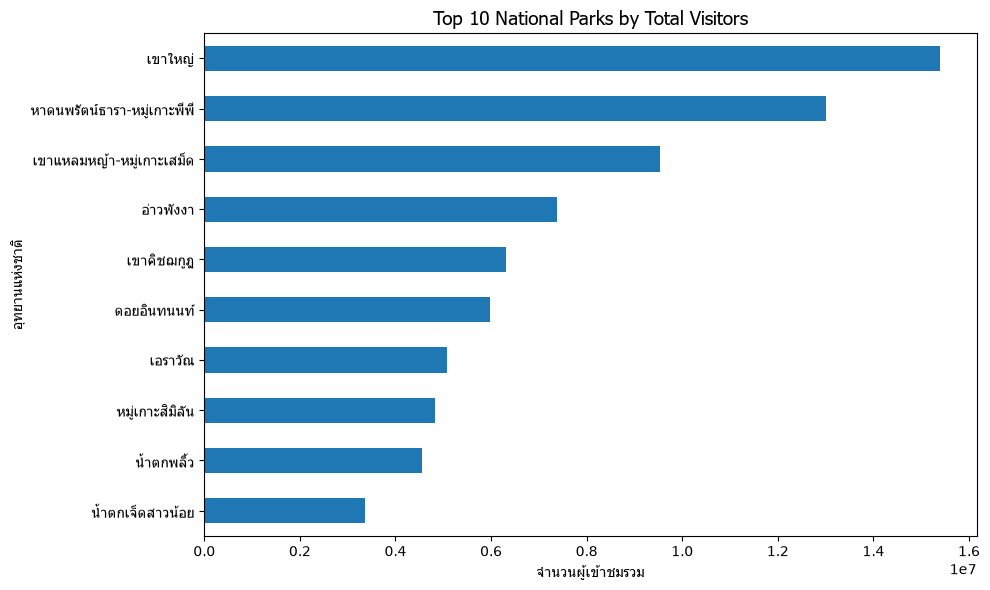

In [71]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

thai_font = font_manager.FontProperties(
    fname=r"C:\Windows\Fonts\tahoma.ttf"
)

top10_parks = park_total.head(10).sort_values()

plt.figure(figsize=(10, 6))

top10_parks.plot(kind="barh")

plt.title(
    "Top 10 National Parks by Total Visitors",
    fontproperties=thai_font,
    fontsize=14
)

plt.xlabel(
    "จำนวนผู้เข้าชมรวม",
    fontproperties=thai_font
)

plt.ylabel(
    "อุทยานแห่งชาติ",
    fontproperties=thai_font
)

plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()

35. วิเคราะห์อุทยานยอดนิยมตามปีที่เลือก

กรองข้อมูลตามปีงบประมาณที่ต้องการ และจัดอันดับอุทยาน
ตามจำนวนผู้เข้าชมรวมภายในปีนั้น

In [ ]:
selected_year = 2568

park_by_year = (
    tourism_clean[
        tourism_clean["fiscal_year_be"] == selected_year
    ]
    .groupby("park_name")["visitors"]
    .sum()
    .sort_values(ascending=False)
)

park_by_year.head(10)

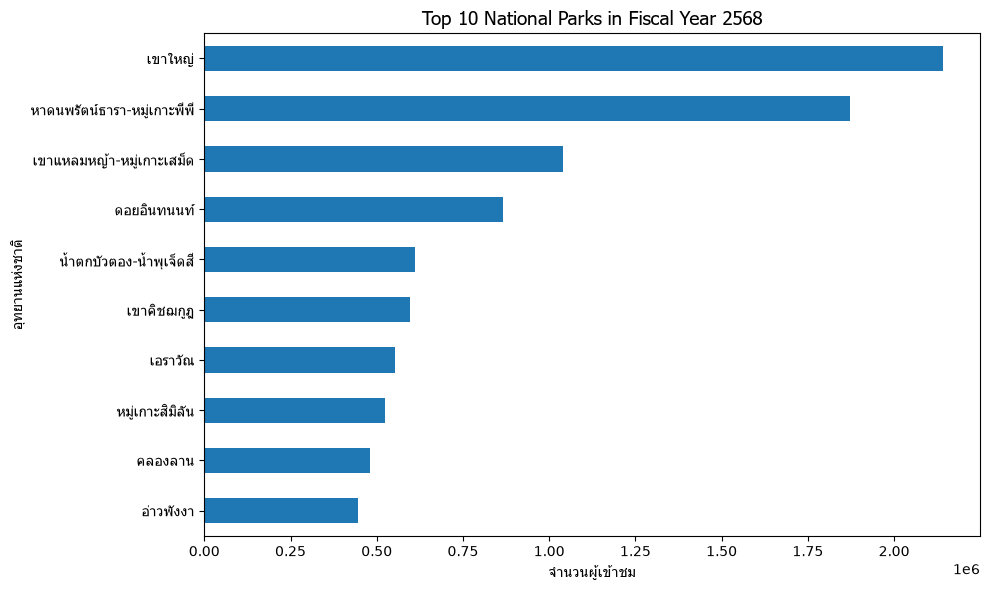

In [73]:
#ทำกราฟแทน
selected_year = 2568

park_by_year = (
    tourism_clean[
        tourism_clean["fiscal_year_be"] == selected_year
    ]
    .groupby("park_name")["visitors"]
    .sum()
    .sort_values(ascending=False)
)

top10_year = park_by_year.head(10).sort_values()

plt.figure(figsize=(10, 6))

top10_year.plot(kind="barh")

plt.title(
    f"Top 10 National Parks in Fiscal Year {selected_year}",
    fontproperties=thai_font,
    fontsize=14
)

plt.xlabel(
    "จำนวนผู้เข้าชม",
    fontproperties=thai_font
)

plt.ylabel(
    "อุทยานแห่งชาติ",
    fontproperties=thai_font
)

plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()

36. วิเคราะห์จำนวนนักท่องเที่ยวรายเดือนของอุทยานที่เลือก

แสดงแนวโน้มจำนวนผู้เข้าชมรายเดือนของอุทยานในปีงบประมาณที่เลือก
เพื่อดูช่วงที่มีนักท่องเที่ยวหนาแน่นและช่วงที่มีผู้เข้าชมน้อย

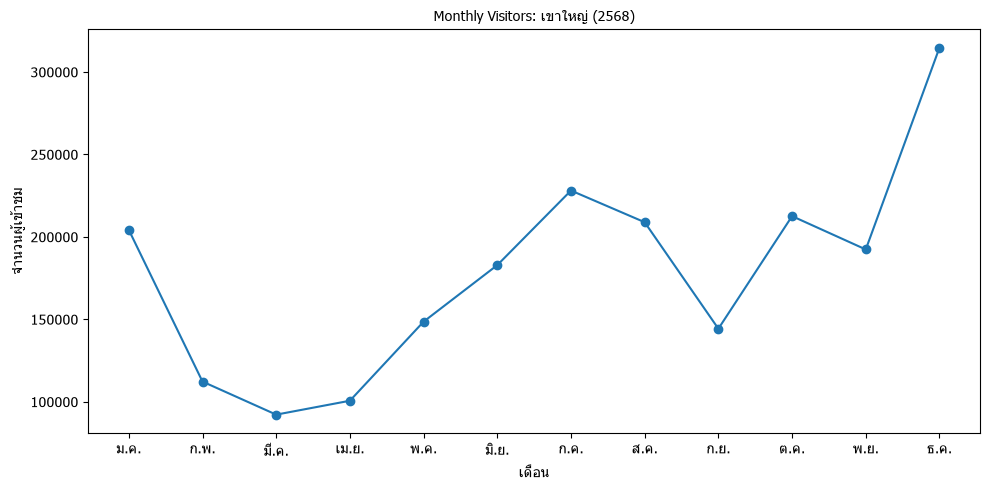

In [76]:
selected_year = 2568
selected_park = "เขาใหญ่"

monthly_trend = (
    tourism_clean[
        (tourism_clean["fiscal_year_be"] == selected_year) &
        (tourism_clean["park_name"] == selected_park)
    ]
    .sort_values("month_num")
)

monthly_trend[
    ["month_th", "visitors"]
]

#กราฟ
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend["month_th"],
    monthly_trend["visitors"],
    marker="o"
)

plt.title(
    f"Monthly Visitors: {selected_park} ({selected_year})",
    fontproperties=thai_font
)

plt.xlabel("เดือน", fontproperties=thai_font)
plt.ylabel("จำนวนผู้เข้าชม", fontproperties=thai_font)

plt.xticks(fontproperties=thai_font)
plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()

 37. แนวโน้มจำนวนผู้เข้าชมรายปี

เปรียบเทียบจำนวนผู้เข้าชมรวมของอุทยานที่เลือกในแต่ละปี
เพื่อดูแนวโน้มการเพิ่มขึ้นหรือลดลงของนักท่องเที่ยว

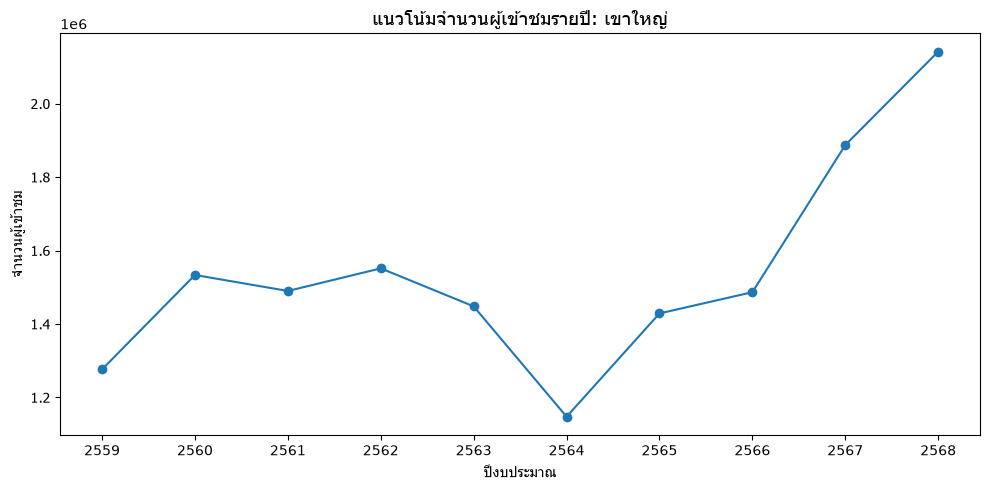

In [83]:
selected_park = "เขาใหญ่"

yearly_park = (
    tourism_clean[
        tourism_clean["park_name"] == selected_park
    ]
    .groupby("fiscal_year_be")["visitors"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_park["fiscal_year_be"],
    yearly_park["visitors"],
    marker="o"
)

plt.title(
    f"แนวโน้มจำนวนผู้เข้าชมรายปี: {selected_park}",
    fontproperties=thai_font,
    fontsize=14
)

plt.xlabel("ปีงบประมาณ", fontproperties=thai_font)
plt.ylabel("จำนวนผู้เข้าชม", fontproperties=thai_font)

plt.xticks(yearly_park["fiscal_year_be"])
plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()

38. วิเคราะห์จำนวนผู้เข้าชมตามสำนักงาน

เปรียบเทียบจำนวนผู้เข้าชมรวมของแต่ละสำนักบริหารพื้นที่อนุรักษ์
ในปีงบประมาณที่เลือก

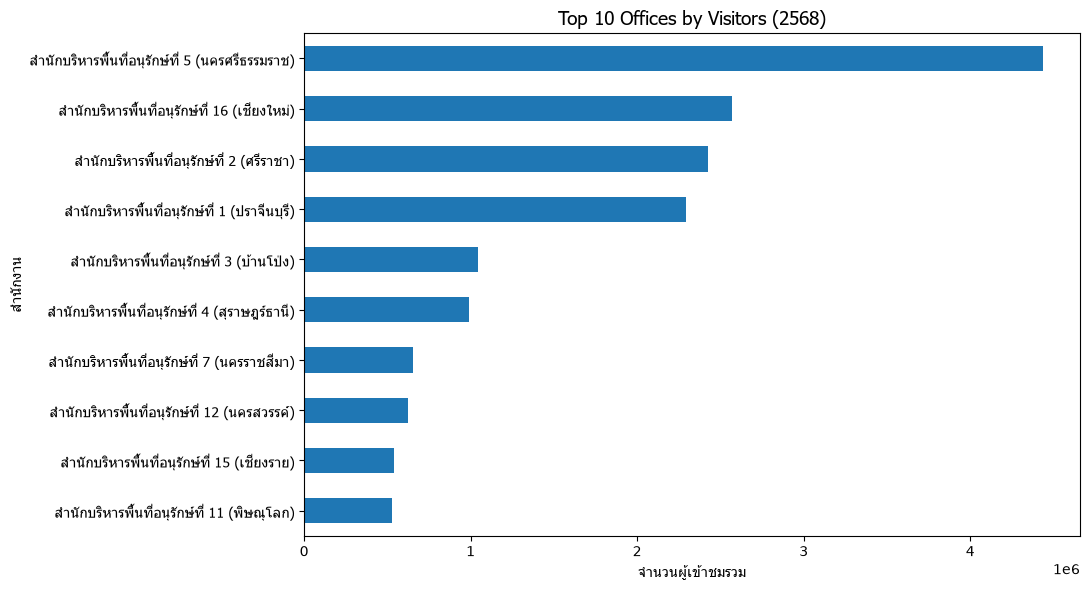

In [84]:
selected_year = 2568 #ถ้านี่เปลี่ยนกราฟก็เปลี่ยนตามปีเหมือน Dashboard

office_total = (
    tourism_clean[
        tourism_clean["fiscal_year_be"] == selected_year
    ]
    .groupby("office")["visitors"]
    .sum()
    .sort_values(ascending=False)
)

top_offices = office_total.head(10).sort_values()

plt.figure(figsize=(11, 6))

top_offices.plot(kind="barh")

plt.title(
    f"Top 10 Offices by Visitors ({selected_year})",
    fontproperties=thai_font,
    fontsize=14
)

plt.xlabel("จำนวนผู้เข้าชมรวม", fontproperties=thai_font)
plt.ylabel("สำนักงาน", fontproperties=thai_font)

plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()

39. วิเคราะห์รูปแบบตามฤดูกาล

วิเคราะห์ค่าเฉลี่ยจำนวนผู้เข้าชมอุทยานในแต่ละเดือน
เพื่อดูรูปแบบฤดูกาลท่องเที่ยวและช่วงที่มีผู้เข้าชมสูงหรือต่ำ

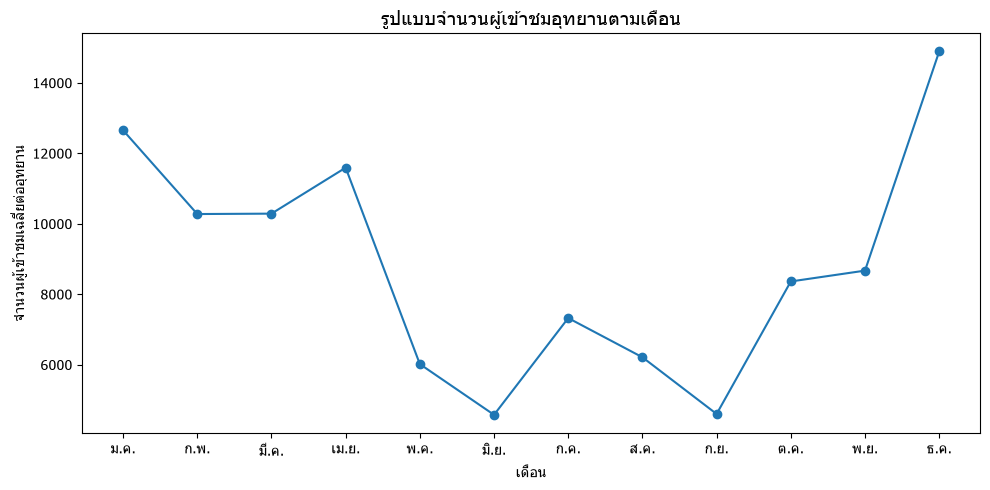

In [85]:
seasonality = (
    tourism_clean
    .groupby(["month_num", "month_th"])["visitors"]
    .mean()
    .reset_index()
    .sort_values("month_num")
)

plt.figure(figsize=(10, 5))

plt.plot(
    seasonality["month_th"],
    seasonality["visitors"],
    marker="o"
)

plt.title(
    "รูปแบบจำนวนผู้เข้าชมอุทยานตามเดือน",
    fontproperties=thai_font,
    fontsize=14
)

plt.xlabel("เดือน", fontproperties=thai_font)
plt.ylabel("จำนวนผู้เข้าชมเฉลี่ยต่ออุทยาน", fontproperties=thai_font)

plt.xticks(fontproperties=thai_font)
plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()